In [ ]:
import pandas as pd
import sys, os, re
import numpy as np
import warnings
warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('../..'))
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt


In [28]:
from ai.utils.integral import Integral
from ai.utils.printer import Printer
from ai.utils.expr.expr_node import ExprNode
from ai.utils.expr.trig.expr_sin import SinExprNode
from ai.utils.expr.trig.expr_cos import CosExprNode
from ai.utils.expr.trig.expr_tan import TanExprNode
from ai.utils.expr.operation.expr_add import AddExprNode
from ai.utils.expr.operation.expr_sub import SubExprNode
from ai.utils.expr.operation.expr_mul import MulExprNode
from ai.utils.expr.operation.expr_frac import FracExprNode
from ai.utils.expr.value.expr_var import VarExprNode
from ai.utils.expr.value.expr_const import ConstExprNode
from ai.utils.expr.Power.expr_mono import MonoExprNode
from ai.utils.expr.expr_log import LogExprNode
from ai.utils.expr.Power.expr_sqrt import SqrtExprNode
from ai.utils.expr.Power.expr_power import PowerExprNode

Tổng mẫu: 3468
Features: 121
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]

Phân phối nhãn:
  action=0: 479 (13.8%)
  action=1: 429 (12.4%)
  action=2: 1347 (38.8%)
  action=3: 800 (23.1%)
  action=4: 413 (11.9%)


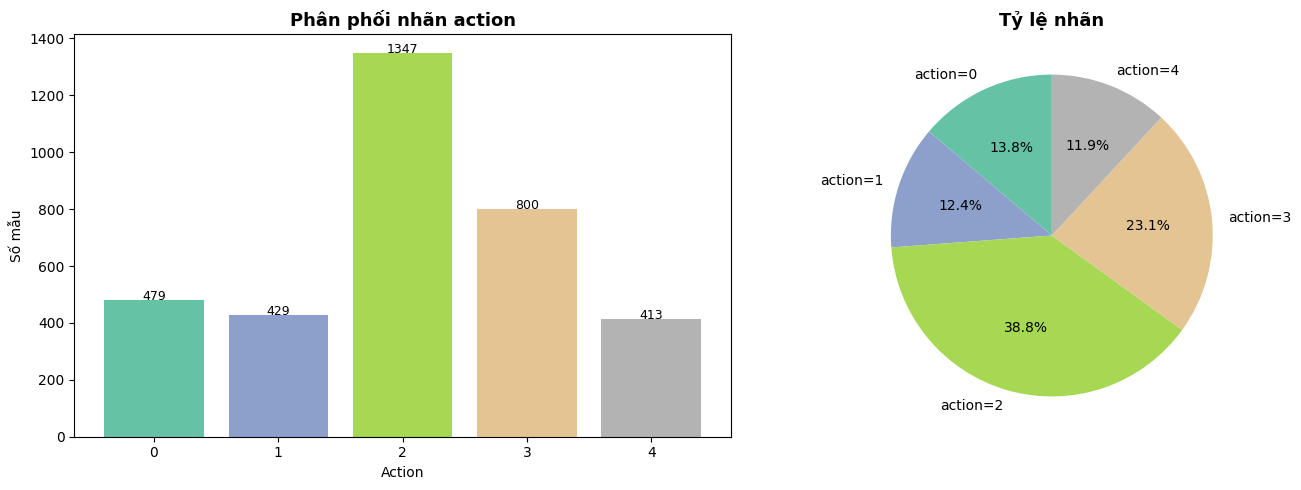

Đã lưu label_distribution.png


In [29]:
df = pd.read_csv('../data/processed/integral_dataset.csv')
df['label'] = pd.to_numeric(df['label'], errors='coerce').astype('Int64')
df = df.dropna(subset=['label'])

y = df['label'].astype(int)
X = df.drop(columns=['label'])

print(f'Tổng mẫu: {len(df)}')
print(f'Features: {X.shape[1]}')
print(f'Classes: {sorted(y.unique())}')

cnt = Counter(y)
print('\nPhân phối nhãn:')
for k in sorted(cnt): 
    print(f'  action={k}: {cnt[k]} ({cnt[k]/len(y)*100:.1f}%)')

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = sorted(cnt.keys())
values = [cnt[k] for k in labels]
colors = plt.cm.Set2(np.linspace(0, 1, len(labels)))

axes[0].bar([str(l) for l in labels], values, color=colors)
axes[0].set_title('Phân phối nhãn action', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Action')
axes[0].set_ylabel('Số mẫu')
for i, v in enumerate(values):
    axes[0].text(i, v+0.2, str(v), ha='center', fontsize=9)

axes[1].pie(values, labels=[f'action={l}' for l in labels],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Tỷ lệ nhãn', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()
print('Đã lưu label_distribution.png')

In [30]:
classes = np.unique(y)
class_weights = compute_class_weight('balanced', classes=classes, y=y)
cw_dict = dict(zip(classes, class_weights))

print('⚖️  Class weights (balanced):')
for k in sorted(cw_dict):
    bar = '█' * int(cw_dict[k])
    print(f'  action={k:3d}: {cw_dict[k]:.3f}  {bar}')

⚖️  Class weights (balanced):
  action=  0: 1.448  █
  action=  1: 1.617  █
  action=  2: 0.515  
  action=  3: 0.867  
  action=  4: 1.679  █


In [1]:


def visualize_gnn_state(model, latex_str, title_suffix="Before Training"):
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    import numpy as np
    import matplotlib.colors as mcolors
    import networkx as nx

    res = expr_to_graph_with_labels(latex_str)
    if res is None:
        print(f"Cannot parse: {latex_str}")
        return
    data, G, pos, nodes_info = res
    
    device = next(model.parameters()).device
    data = data.to(device)
    embeddings, probs = get_model_predictions_and_embeddings(model, data)
    
    num_nodes = len(nodes_info)
    if num_nodes >= 2:
        pca = PCA(n_components=min(2, num_nodes))
        coords = pca.fit_transform(embeddings)
        if coords.shape[1] == 1:
            coords = np.column_stack((coords, np.zeros(num_nodes)))
    else:
        coords = np.zeros((num_nodes, 2))
        
    ACTION_NAMES = [
        "Rut hang so",
        "Tach tong/hieu",
        "Cong thuc dac trung",
        "Doi bien u=ax+b",
        "Tich phan tung phan"
    ]
    
    colors_palette = list(mcolors.TABLEAU_COLORS.values())
    node_types = list(NODE_TYPE_MAP.keys())
    type_to_color = {nt: colors_palette[i % len(colors_palette)] for i, nt in enumerate(node_types)}
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"GNN State: {latex_str} ({title_suffix})", fontsize=14, fontweight='bold')
    
    # Subplot 1: Tree Graph
    ax1 = axes[0]
    ax1.set_title("Expression Tree Structure")
    node_colors = [type_to_color.get(G.nodes[n]['type'], '#94a3b8') for n in G.nodes()]
    labels = {n: G.nodes[n]['label'] for n in G.nodes()}
    nx.draw_networkx_nodes(G, pos, ax=ax1, node_color=node_colors, node_size=500, alpha=0.9, edgecolors='black')
    nx.draw_networkx_edges(G, pos, ax=ax1, arrowstyle='->', arrowsize=12, width=1.5, edge_color='gray')
    nx.draw_networkx_labels(G, pos, labels, ax=ax1, font_size=9, font_weight='bold')
    ax1.axis('off')
    
    # Subplot 2: PCA Node Embeddings
    ax2 = axes[1]
    ax2.set_title("Node Embeddings (PCA 2D)")
    scatter_colors = [type_to_color.get(nodes_info[i]['type'], '#94a3b8') for i in range(num_nodes)]
    ax2.scatter(coords[:, 0], coords[:, 1], c=scatter_colors, s=100, edgecolors='black', alpha=0.8)
    for i in range(num_nodes):
        ax2.annotate(nodes_info[i]['label'], (coords[i, 0], coords[i, 1]), textcoords="offset points", xytext=(0, 6), ha='center', fontweight='bold', fontsize=8)
    ax2.grid(True, linestyle='--', alpha=0.5)
    ax2.set_xlabel("PC1")
    ax2.set_ylabel("PC2")
    
    # Subplot 3: Probabilities
    ax3 = axes[2]
    ax3.set_title("Action Predictions")
    y_pos = np.arange(len(ACTION_NAMES))
    bar_colors = ['#3b82f6' if p == max(probs) else '#94a3b8' for p in probs]
    bars = ax3.barh(y_pos, probs * 100, align='center', color=bar_colors, edgecolor='black', alpha=0.9)
    ax3.set_yticks(y_pos)
    ax3.set_yticklabels(ACTION_NAMES, fontweight='semibold')
    ax3.invert_yaxis()
    ax3.set_xlabel('Probability (%)')
    ax3.set_xlim(0, 100)
    for bar in bars:
        w = bar.get_width()
        ax3.text(w + 1, bar.get_y() + bar.get_height()/2, f'{w:.1f}%', ha='left', va='center', fontweight='bold', fontsize=8)
        
    plt.tight_layout()
    plt.show()

def evaluate_embedding_separability(model, loader, title_suffix="Before Training"):
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    from sklearn.metrics import silhouette_score
    import numpy as np

    model.eval()
    all_embeddings = []
    all_labels = []
    device = next(model.parameters()).device

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            x, edge_index, batch = data.x, data.edge_index, data.batch
            x1 = F.relu(model.conv1(x, edge_index))
            x2 = F.relu(model.conv2(x1, edge_index))
            x3 = F.relu(model.conv3(x2, edge_index))
            pooled = global_mean_pool(x3, batch)
            
            all_embeddings.append(pooled.cpu().numpy())
            all_labels.append(data.y.cpu().numpy())

    embeddings = np.concatenate(all_embeddings, axis=0)
    labels = np.concatenate(all_labels, axis=0)

    score = silhouette_score(embeddings, labels)
    print(f"[{title_suffix}] Silhouette Score of Graph Embeddings: {score:.4f}")

    pca = PCA(n_components=2)
    coords = pca.fit_transform(embeddings)

    ACTION_NAMES = [
        "Rut hang so",
        "Tach tong/hieu",
        "Cong thuc dac trung",
        "Doi bien u=ax+b",
        "Tich phan tung phan"
    ]
    
    plt.figure(figsize=(10, 8))
    colors = ['#ef4444', '#3b82f6', '#10b981', '#f59e0b', '#8b5cf6']
    for class_idx in range(len(ACTION_NAMES)):
        mask = (labels == class_idx)
        plt.scatter(
            coords[mask, 0], coords[mask, 1],
            label=f"{class_idx}: {ACTION_NAMES[class_idx]}",
            alpha=0.7, edgecolors='black', linewidth=0.5, s=60, color=colors[class_idx]
        )

    plt.title(f"GNN Graph Embeddings Separability ({title_suffix})\nSilhouette Score: {score:.4f}", fontsize=13, fontweight='bold')
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(frameon=True, facecolor='white', edgecolor='gray')
    plt.tight_layout()
    plt.show()
print("Da khai bao cac ham Helper Visualizer & Separability Check.")

Da khai bao cac ham Helper Visualizer & Separability Check.


In [ ]:
evaluate_embedding_separability(model, test_loader, "Before Training - Test Set")

In [31]:
y_clean = df["label"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y_clean,
    test_size=0.2,
    random_state=42,
    stratify=y_clean
)

print(f'Train: {X_train.shape[0]} mẫu | Test: {X_test.shape[0]} mẫu')

# Tính class weights trên tập train
classes_train = np.unique(y_train)
cw_train = compute_class_weight('balanced', classes=classes_train, y=y_train)
cw_dict_train = dict(zip(classes_train, cw_train))
print(f'Class weights train: {cw_dict_train}')

Train: 2774 mẫu | Test: 694 mẫu
Class weights train: {np.int64(0): np.float64(1.4485639686684073), np.int64(1): np.float64(1.6174927113702624), np.int64(2): np.float64(0.514656771799629), np.int64(3): np.float64(0.866875), np.int64(4): np.float64(1.6812121212121212)}


In [ ]:
min_count = min(Counter(y_train).values())
n_splits = min(5, min_count)
print(f'Dùng {n_splits}-fold CV (min class count = {min_count})')

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(class_weight='balanced', probability=True, random_state=42))
])

param_grid_svm = [
    {'svm__kernel': ['rbf'], 'svm__C': [0.1, 1, 10, 100], 'svm__gamma': ['scale', 'auto', 0.01, 0.1]},
    {'svm__kernel': ['linear'], 'svm__C': [0.1, 1, 10]},
    {'svm__kernel': ['poly'], 'svm__C': [0.1, 1, 10], 'svm__degree': [2, 3]}
]
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
gs_svm = GridSearchCV(
    svm_pipeline, param_grid_svm, cv=cv,
    scoring='f1_macro', n_jobs=-1, verbose=0
)
gs_svm.fit(X_train, y_train)
print(f'\nSVM Best params: {gs_svm.best_params_}')
print(f'SVM Best CV F1-macro: {gs_svm.best_score_:.4f}')
y_pred_svm = gs_svm.predict(X_test)
f1_svm = f1_score(y_test, y_pred_svm, average='macro', zero_division=0)
print(f'\nSVM Test F1-macro: {f1_svm:.4f}')
print(classification_report(y_test, y_pred_svm, zero_division=0))

Dùng 5-fold CV (min class count = 330)


In [ ]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        class_weight='balanced_subsample',
        random_state=42, n_jobs=-1
    ))
])

param_grid_rf = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [None, 5, 10],
    'rf__min_samples_split': [2, 5]
}

gs_rf = GridSearchCV(
    rf_pipeline, param_grid_rf, cv=cv,
    scoring='f1_macro', n_jobs=-1, verbose=0
)

gs_rf.fit(X_train, y_train)
print(f'\nRF Best params: {gs_rf.best_params_}')
print(f'RF Best CV F1-macro: {gs_rf.best_score_:.4f}')

y_pred_rf = gs_rf.predict(X_test)


RF Best params: {'rf__max_depth': 10, 'rf__min_samples_split': 5, 'rf__n_estimators': 100}
RF Best CV F1-macro: 0.5813


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
sample_weights = np.array([cw_dict_train.get(label, 1.0) for label in y_train])

gb = GradientBoostingClassifier(
    n_estimators=200, learning_rate=0.1,
    max_depth=4, random_state=42
)

print('Đang train Gradient Boosting...')
gb.fit(X_train, y_train, sample_weight=sample_weights)

y_pred_gb = gb.predict(X_test)
f1_gb = f1_score(y_test, y_pred_gb, average='macro', zero_division=0)
print(f'\nGB Test F1-macro: {f1_gb:.4f}')
print(classification_report(y_test, y_pred_gb, zero_division=0))

Đang train Gradient Boosting...

GB Test F1-macro: 0.5476
              precision    recall  f1-score   support

         0.0       0.46      0.40      0.43        96
         1.0       0.55      0.58      0.56        86
         2.0       0.77      0.67      0.72       269
         3.0       0.49      0.54      0.52       160
         4.0       0.45      0.59      0.51        83

    accuracy                           0.58       694
   macro avg       0.55      0.56      0.55       694
weighted avg       0.60      0.58      0.59       694



In [ ]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
cnt_train = Counter(y_train)
valid_classes = [k for k, v in cnt_train.items() if v >= 2]
mask = y_train.isin(valid_classes)
X_tr_sm, y_tr_sm = X_train[mask], y_train[mask]

k_neighbors = min(3, min(Counter(y_tr_sm).values()) - 1)
smote = SMOTE(k_neighbors=max(1, k_neighbors), random_state=42)

In [ ]:
try:
   
    X_res, y_res = smote.fit_resample(X_tr_sm, y_tr_sm)
    print(f'SMOTE: {len(y_tr_sm)} → {len(y_res)} mẫu')
    print('Phân phối sau SMOTE:', Counter(y_res))
    svm_smote = Pipeline([
        ('scaler', StandardScaler()),
        ('svm', SVC(class_weight='balanced', probability=True, random_state=42,
                    kernel='rbf', C=10, gamma='scale'))
    ])
    svm_smote.fit(X_res, y_res)
    y_pred_smote = svm_smote.predict(X_test)
    f1_smote = f1_score(y_test, y_pred_smote, average='macro', zero_division=0)
    print(f'\nSVM+SMOTE Test F1-macro: {f1_smote:.4f}')
    print(classification_report(y_test, y_pred_smote, zero_division=0))

except ImportError:
    f1_smote = 0
    print('imbalanced-learn chưa cài. Chạy: pip install imbalanced-learn')

SMOTE: 2774 → 5390 mẫu
Phân phối sau SMOTE: Counter({np.int64(3): 1078, np.int64(2): 1078, np.int64(4): 1078, np.int64(1): 1078, np.int64(0): 1078})

SVM+SMOTE Test F1-macro: 0.5454
              precision    recall  f1-score   support

         0.0       0.44      0.42      0.43        96
         1.0       0.52      0.57      0.54        86
         2.0       0.79      0.65      0.71       269
         3.0       0.49      0.56      0.52       160
         4.0       0.47      0.59      0.52        83

    accuracy                           0.58       694
   macro avg       0.54      0.56      0.55       694
weighted avg       0.60      0.58      0.59       694




BẢNG SO SÁNH MODEL
  SVM (balanced)           : 0.5482 ← BEST
  Gradient Boosting        : 0.5476
  SVM + SMOTE              : 0.5454


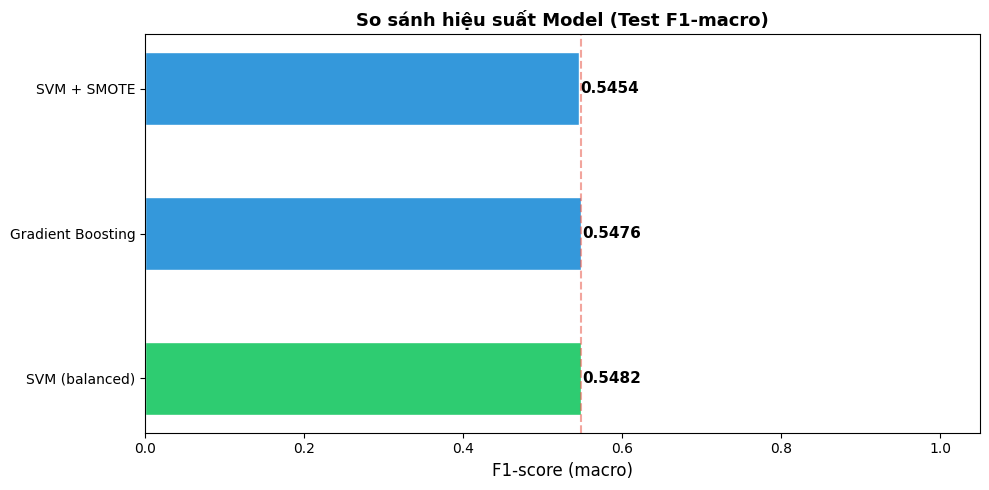

Đã lưu model_comparison.png


In [ ]:
results = {
    'SVM (balanced)': f1_svm,
    # 'Random Forest': f1_rf,
    'Gradient Boosting': f1_gb,
    'SVM + SMOTE': f1_smote
}

print('\n' + '='*45)
print('BẢNG SO SÁNH MODEL')
print('='*45)
best_name = max(results, key=results.get)
for name, score in sorted(results.items(), key=lambda x: -x[1]):
    marker = ' ← BEST' if name == best_name else ''
    print(f'  {name:25s}: {score:.4f}{marker}')
print('='*45)

# Visualize
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
scores = list(results.values())
colors = ['#2ecc71' if n == best_name else '#3498db' for n in names]
bars = ax.barh(names, scores, color=colors, edgecolor='white', height=0.5)
for bar, score in zip(bars, scores):
    ax.text(score + 0.002, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.set_xlabel('F1-score (macro)', fontsize=12)
ax.set_title('So sánh hiệu suất Model (Test F1-macro)', fontsize=13, fontweight='bold')
ax.axvline(x=scores[names.index(best_name)], color='#e74c3c', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
print('Đã lưu model_comparison.png')

In [ ]:
import joblib, os

save_dir = '../saved_models'
os.makedirs(save_dir, exist_ok=True)

model_path = os.path.join(save_dir, 'best_model.pkl')
joblib.dump(gb, model_path)
print(f'Đã lưu best model: {best_name}')
print(f'   → {model_path}')
print(f'   F1-macro (test): {results[best_name]:.4f}')

# Lưu meta info
import json
meta = {
    'best_model': best_name,
    'f1_macro_test': results[best_name],
    'all_results': {k: round(v, 4) for k, v in results.items()},
    'n_classes': len(sorted(y_clean.unique())),
    'classes': sorted(int(c) for c in y_clean.unique())
}
with open(os.path.join(save_dir, 'model_meta.json'), 'w') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False)
print('Đã lưu model_meta.json')

Đã lưu best model: SVM (balanced)
   → ../saved_models\best_model.pkl
   F1-macro (test): 0.5482
Đã lưu model_meta.json


MA TRẬN NHẦM LẪN CỦA MÔ HÌNH GRADIENT BOOSTING (BEST MODEL):


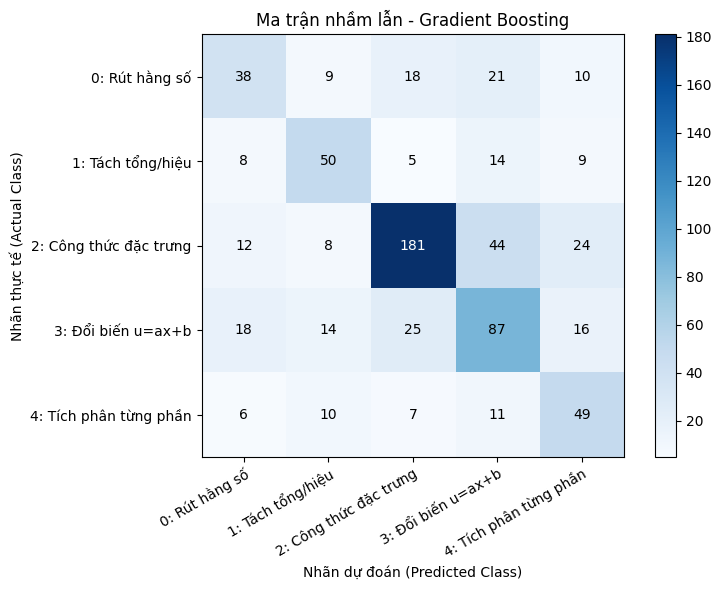


MA TRẬN NHẦM LẪN CỦA MÔ HÌNH SVM:


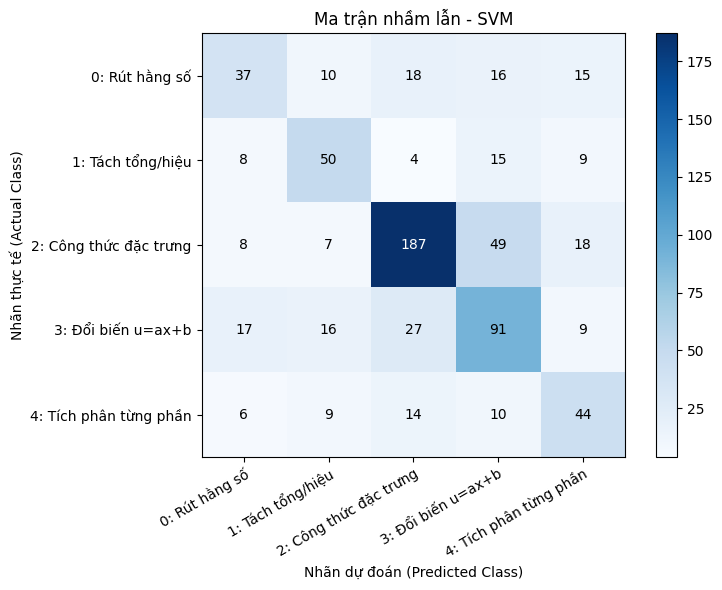

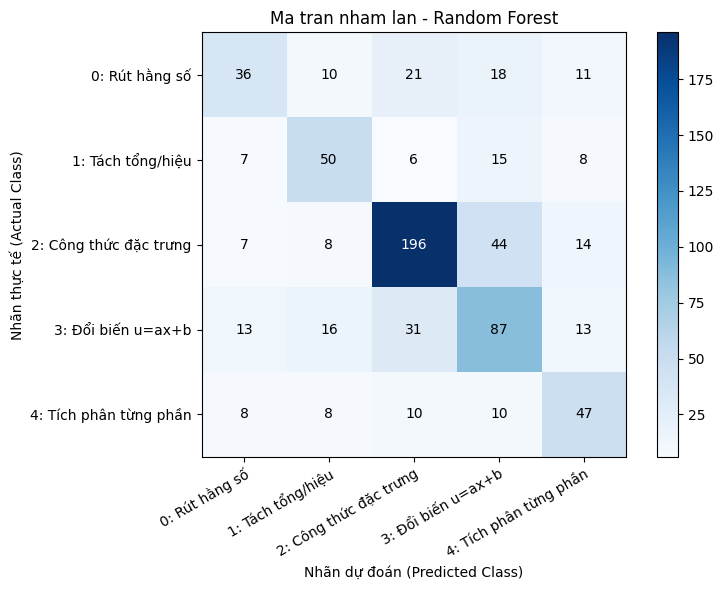

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

action_names = [
    "0: Rút hằng số",
    "1: Tách tổng/hiệu",
    "2: Công thức đặc trưng",
    "3: Đổi biến u=ax+b",
    "4: Tích phân từng phần"
]

def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    try:
        import seaborn as sns
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm, 
            annot=True, 
            fmt="d", 
            cmap="Blues", 
            xticklabels=action_names, 
            yticklabels=action_names
        )
        plt.title(title, fontsize=14, pad=15)
        plt.xlabel("Nhãn dự đoán (Predicted Class)", fontsize=12, labelpad=10)
        plt.ylabel("Nhãn thực tế (Actual Class)", fontsize=12, labelpad=10)
        plt.xticks(rotation=30, ha="right")
        plt.yticks(rotation=0)
        plt.tight_layout()
        plt.show()
    except ImportError:
        fig, ax = plt.subplots(figsize=(8, 6))
        im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
        ax.figure.colorbar(im, ax=ax)
        ax.set(xticks=np.arange(cm.shape[1]),
               yticks=np.arange(cm.shape[0]),
               xticklabels=action_names, yticklabels=action_names,
               title=title,
               ylabel="Nhãn thực tế (Actual Class)",
               xlabel="Nhãn dự đoán (Predicted Class)")
        plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")
        thresh = cm.max() / 2.
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                ax.text(j, i, format(cm[i, j], 'd'),
                        ha="center", va="center",
                        color="white" if cm[i, j] > thresh else "black")
        fig.tight_layout()
        plt.show()

# Hiển thị ma trận nhầm lẫn cho mô hình tốt nhất (Gradient Boosting)
print("MA TRẬN NHẦM LẪN CỦA MÔ HÌNH GRADIENT BOOSTING (BEST MODEL):")
plot_confusion_matrix(y_test, y_pred_gb, "Ma trận nhầm lẫn - Gradient Boosting")

# Hiển thị cho SVM
print("\nMA TRẬN NHẦM LẪN CỦA MÔ HÌNH SVM:")
plot_confusion_matrix(y_test, y_pred_svm, "Ma trận nhầm lẫn - SVM")
plot_confusion_matrix(y_test, y_pred_rf, "Ma tran nham lan - Random Forest")
